# Quantum Computing Lab — Teacher's Notebook (Solutions)

This is the **teacher's copy** of `exercises_student.ipynb` with every exercise **fully solved**, the expected outputs documented, and notes on what to point out in class.

Use it to:
- run a demonstration before the students attempt the exercises,
- compare against their solutions,
- answer follow-up questions (each solution cell notes the *why*).

The order of exercises is identical to the student notebook, so you can follow both side by side.

In [15]:
# Setup — run this first
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Latex
from qiskit import QuantumCircuit
from qclab.runner import simulate, run_on_ibm
from qclab.states import statevector_of, matrix_of, matrix_to_latex
from qclab.viz import draw_circuit, plot_counts, plot_statevector
from qclab.check import assert_statevector, assert_distribution

import qiskit
print("Qiskit:", qiskit.__version__)

Qiskit: 2.5.2


> **Teaching note:** the student notebook contains the full concept introduction (qubits, superposition, measurement, Dirac notation, the qubit-ordering convention, gates). This notebook skips most of that prose — refer students to the student notebook for the theory. The short recap below is all you need to run the demos.

**Recap:** $|\psi\rangle = \sum_i \alpha_i |i\rangle$, $|\alpha_i|^2$ = probability of measuring bit-string $i$, leftmost bit = highest-numbered qubit, gates are unitary matrices, real hardware returns counts only.

# Solution 1 — One qubit in perfect superposition

**Answer:** a single Hadamard gate is enough. $H|0\rangle = \tfrac{|0\rangle+|1\rangle}{\sqrt{2}}$.

**Expected output:** counts ≈ 512/512 (± statistical noise); statevector $[0.707, 0.707]$; H matrix $\tfrac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$.

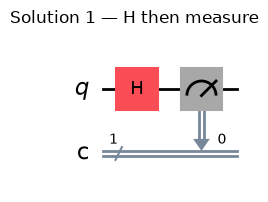

In [2]:
from qiskit.circuit.library import HGate, XGate, CXGate

q1 = QuantumCircuit(1, 1)
q1.h(0)          # superposition
q1.measure(0, 0) # measurement
draw_circuit(q1, "Solution 1 — H then measure")

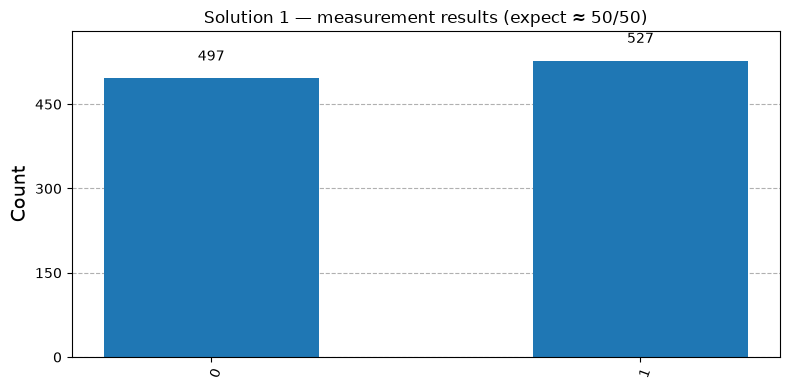

In [3]:
counts = simulate(q1, shots=1024)
plot_counts(counts, "Solution 1 — measurement results (expect ≈ 50/50)")

In [4]:
display(Latex(matrix_to_latex(matrix_of(HGate()))))
assert_statevector(q1, {"0": 1/np.sqrt(2), "1": 1/np.sqrt(2)}, message="Solution 1 state")
assert_distribution(counts, {"0": 0.5, "1": 0.5}, message="Solution 1 counts")
print("✅ Solution 1 verified")

<IPython.core.display.Latex object>

✅ Solution 1 verified


---
# Solution 2 — The four Bell states

**Answer:** for each starting state, `H(0)` then `CX(0,1)` (plus `X` gates to set up the starting state).

Resulting Bell states (Qiskit convention, leftmost = highest qubit):

| Start | Bell state | Statevector | Measurement results |
|-------|------------|-------------|---------------------|
| 00 | Φ⁺ | $\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$ | 50% 00, 50% 11 |
| 01 | Φ⁻ | $\tfrac{1}{\sqrt2}(|00\rangle-|11\rangle)$ | 50% 00, 50% 11 |
| 10 | Ψ⁺ | $\tfrac{1}{\sqrt2}(|01\rangle+|10\rangle)$ | 50% 01, 50% 10 |
| 11 | Ψ⁻ | $\tfrac{1}{\sqrt2}(|01\rangle-|10\rangle)$ | 50% 01, 50% 10 |

**The key point to demonstrate:** starts 00 and 01 give *identical counts* but *different internal states* (relative phase $+1$ vs $-1$ on `11`). Same for 10 and 11. Measurement can never distinguish Φ⁺ from Φ⁻ — you need the statevector (simulator only) or a more elaborate interferometric protocol on hardware.

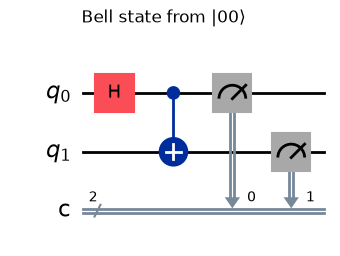

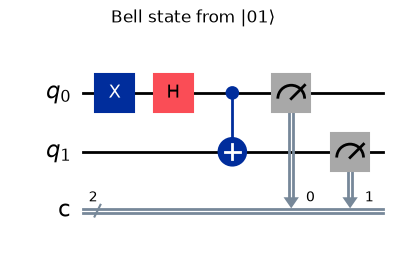

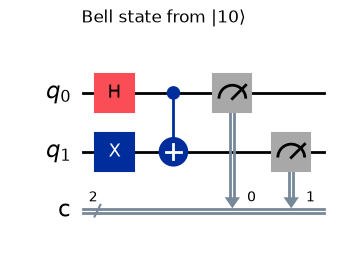

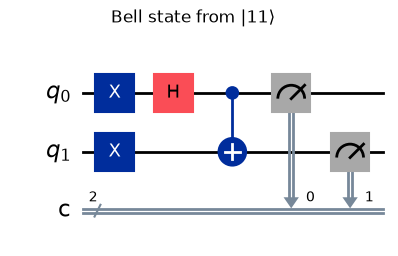

In [5]:
bell_circuits = {}
for start in ["00", "01", "10", "11"]:
    qc = QuantumCircuit(2, 2)
    if start[1] == "1":   # rightmost char of "ab" is qubit 0
        qc.x(0)
    if start[0] == "1":   # leftmost char is qubit 1
        qc.x(1)
    qc.h(0)        # Hadamard on the first qubit
    qc.cx(0, 1)    # CNOT: control qubit 0, target qubit 1
    qc.measure(0, 0)
    qc.measure(1, 1)
    bell_circuits[start] = qc

for start in ["00", "01", "10", "11"]:
    display(draw_circuit(bell_circuits[start], f"Bell state from |{start}⟩"))

|00⟩ → counts {'11': 514, '00': 510}


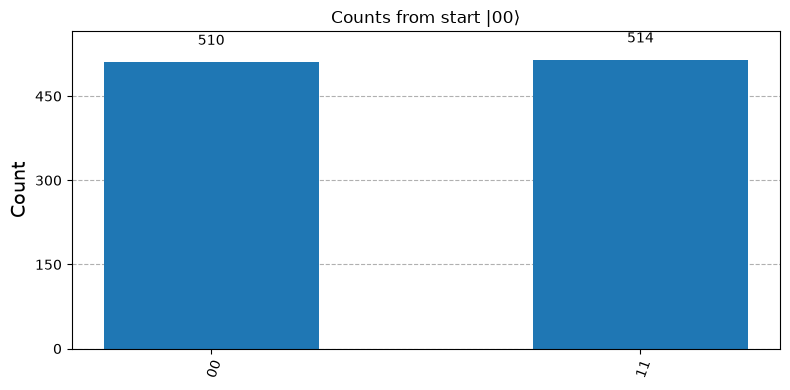

|01⟩ → counts {'11': 533, '00': 491}


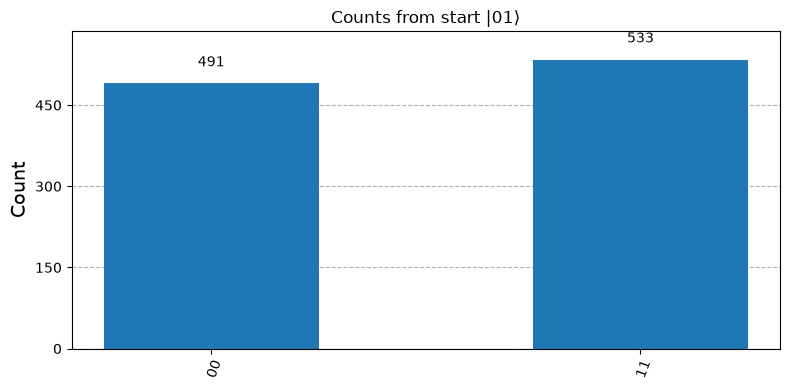

|10⟩ → counts {'10': 494, '01': 530}


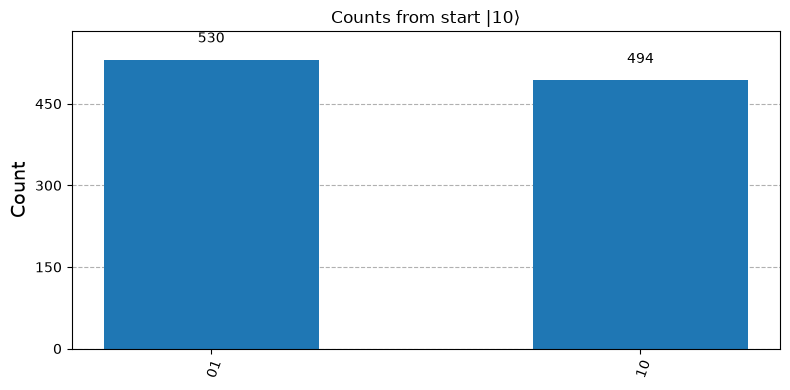

|11⟩ → counts {'01': 501, '10': 523}


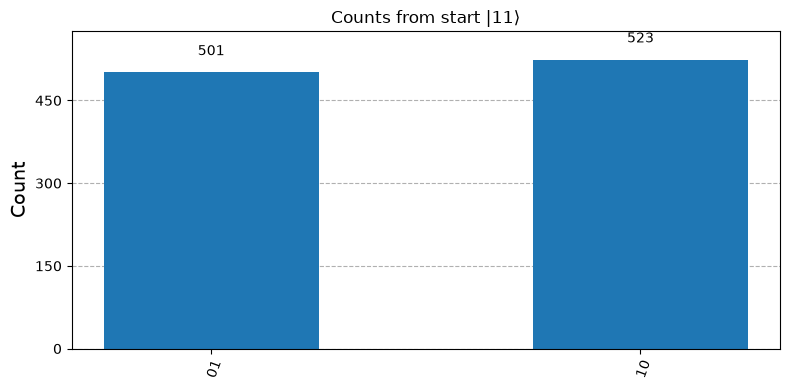

In [6]:
bell_counts = {start: simulate(bell_circuits[start], shots=1024) for start in bell_circuits}
bell_sv = {start: statevector_of(bell_circuits[start]) for start in bell_circuits}

for start in ["00", "01", "10", "11"]:
    print(f"|{start}⟩ → counts {bell_counts[start]}")
    display(plot_counts(bell_counts[start], f"Counts from start |{start}⟩"))

|00⟩ → Φ⁺ : [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]


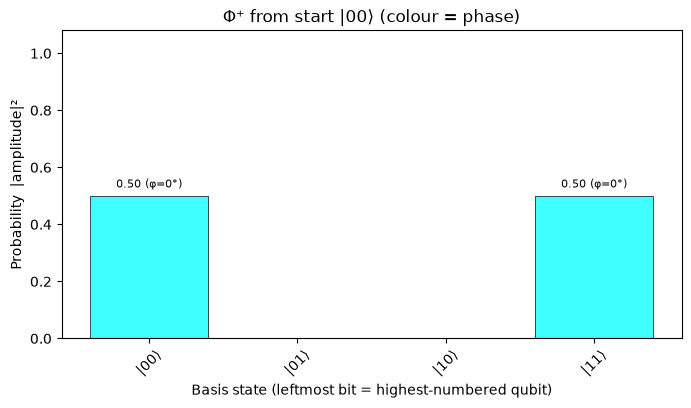

|01⟩ → Φ⁻ : [ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]


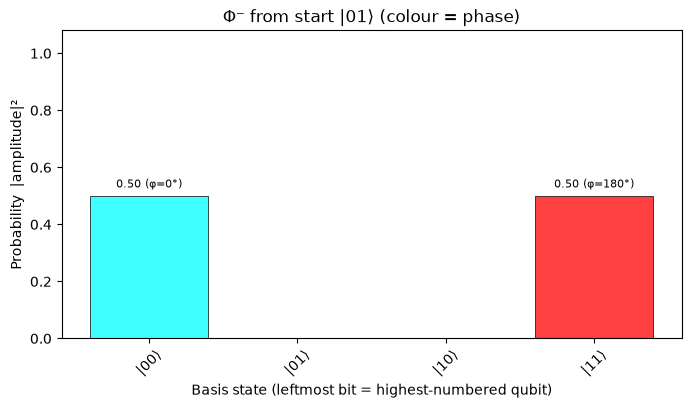

|10⟩ → Ψ⁺ : [0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]


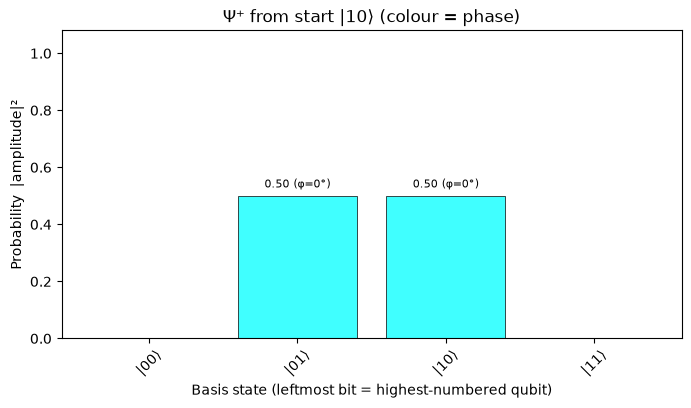

|11⟩ → Ψ⁻ : [ 0.   +0.j -0.707+0.j  0.707+0.j  0.   +0.j]


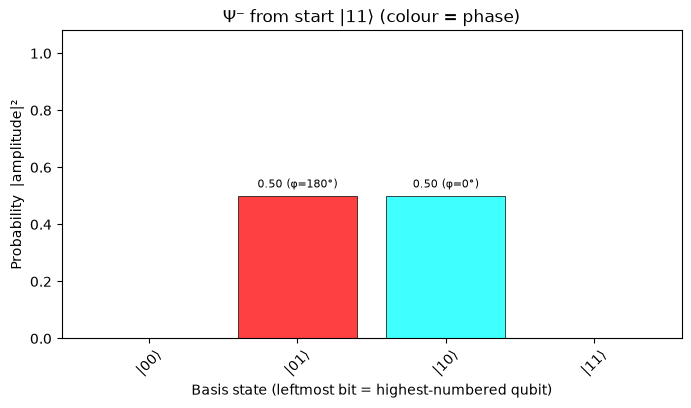

In [7]:
# The internal states — look at the PHASES (bar colours): red = 0°, blue = 180°
names = {"00": "Φ⁺", "01": "Φ⁻", "10": "Ψ⁺", "11": "Ψ⁻"}
for start in ["00", "01", "10", "11"]:
    print(f"|{start}⟩ → {names[start]} :", np.round(bell_sv[start].data, 3))
    display(plot_statevector(bell_sv[start], f"{names[start]} from start |{start}⟩ (colour = phase)"))

In [8]:
# Verify: same counts, different internal state
assert_distribution(bell_counts["00"], {"00": 0.5, "11": 0.5}, message="00")
assert_distribution(bell_counts["01"], {"00": 0.5, "11": 0.5}, message="01")
assert_distribution(bell_counts["10"], {"01": 0.5, "10": 0.5}, message="10")
assert_distribution(bell_counts["11"], {"01": 0.5, "10": 0.5}, message="11")

print("Φ⁺ vs Φ⁻ same internal state?", np.allclose(bell_sv["00"].data, bell_sv["01"].data))
print("Ψ⁺ vs Ψ⁻ same internal state?", np.allclose(bell_sv["10"].data, bell_sv["11"].data))

# Proof by contradiction-style: a strict statevector check must FAIL across the pair
try:
    assert_statevector(bell_circuits["00"], {"00": 1/np.sqrt(2), "11": -1/np.sqrt(2)})
    print("ERROR — should have failed")
except AssertionError:
    print("✅ Φ⁺ circuit is NOT Φ⁻ (statevectors differ even though counts don't)")

Φ⁺ vs Φ⁻ same internal state? False
Ψ⁺ vs Ψ⁻ same internal state? False
✅ Φ⁺ circuit is NOT Φ⁻ (statevectors differ even though counts don't)


---
# Solution 3 — Transformation matrices

**Answer:** H and X are 2×2 unitary matrices; the textbook CNOT (control = q1, target = q0) is the 4×4 block $\begin{pmatrix} I & 0 \\ 0 & X \end{pmatrix}$.

Expected matrices:
$$H = \tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix},\qquad X = \begin{pmatrix}0&1\\1&0\end{pmatrix},\qquad CX = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$$

(CX is written in the basis order $|00\rangle, |01\rangle, |10\rangle, |11\rangle$; it only flips the last two rows/columns — the $|10\rangle \to |11\rangle$, $|11\rangle \to |10\rangle$ swap.)

> **Convention note (the classic confusion):** the CX matrix above is the *standard textbook* one — control = the more-significant qubit (q1), target = q0. Qiskit's **bare `CXGate()`** (no circuit context) defaults to control = qubit 0, target = qubit 1, whose matrix is the mirror image $\begin{pmatrix}1&0&0&0\\0&0&0&1\\0&0&1&0\\0&1&0&0\end{pmatrix}$. Same physical gate, opposite index order. The loop cell below displays the textbook matrix (from a `cx(1,0)` circuit); the Bell/target circuits use `cx(0,1)` / `cx(2,·)` because they seed the *lowest* qubit — both conventions are correct, they just differ in which qubit is the control.

In [9]:
# Textbook convention for CX: control = the more-significant qubit (q1), target = q0.
# (A bare CXGate() defaults to control q0, target q1 — the mirror-image matrix.)
cx_textbook = QuantumCircuit(2)
cx_textbook.cx(1, 0)

for gate, name in [(HGate(), "H"), (XGate(), "X"), (cx_textbook, "CX (control q1 → target q0)")]:
    print(f"Gate {name}:")
    display(Latex(matrix_to_latex(matrix_of(gate))))

Gate H:


<IPython.core.display.Latex object>

Gate X:


<IPython.core.display.Latex object>

Gate CX (control q1 → target q0):


<IPython.core.display.Latex object>

In [10]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
U_bell = matrix_of(bell)
print("Matrix of the full Bell circuit (CX · H on qubit 0):")
display(Latex(matrix_to_latex(U_bell)))

Matrix of the full Bell circuit (CX · H on qubit 0):


<IPython.core.display.Latex object>

In [11]:
from qiskit.quantum_info import Statevector

h = matrix_of(HGate())
result = h @ Statevector.from_label("0")
print("H |0> =", result.data, "  ✅ matches Exercise 1")

# Full-circuit check against Exercise 2 statevectors:
for start in ["00", "01", "10", "11"]:
    by_matrix = (U_bell @ Statevector.from_label(start)).data
    by_circuit = bell_sv[start].data
    print(f"U|{start}\rangle matches circuit statevector? {np.allclose(by_matrix, by_circuit)}")

H |0> = [0.70710678+0.j 0.70710678+0.j]   ✅ matches Exercise 1
angle matches circuit statevector? True
angle matches circuit statevector? True
angle matches circuit statevector? True
angle matches circuit statevector? True


> **Teaching note:** each *column* of $U_{Bell}$ is the image of one basis state. Columns 1 & 3 (inputs `00`, `10`) map to the two Φ states; columns 2 & 4 (inputs `01`, `11`) map to the two Ψ states. Students can read the whole Exercise 2 result off this single matrix.

---
# Solution 4 — Five 3-qubit target states

**Solutions** (recall: leftmost bit = qubit 2):

| # | Target | Gates (in order) | Why |
|---|--------|------------------|-----|
| 1 | 100% `\|101⟩` | `X(2)`, `X(0)` | Fixed state: flip the qubits that should be 1. |
| 2 | 50% `\|000⟩` / 50% `\|111⟩` (GHZ) | `H(0)`, `CX(0,1)`, `CX(0,2)` | Seed on qubit 0; fan out with two CNOTs — all three correlated. |
| 3 | 50% `\|010⟩` / 50% `\|110⟩` | `X(1)`, `H(2)` | Qubit 1 fixed at 1; only qubit 2 varies → just H on qubit 2 (no CNOT needed). |
| 4 | 50% `\|110⟩` / 50% `\|011⟩` | `X(1)`, `X(0)`, `H(2)`, `CX(2,0)` | Qubit 1 fixed at 1. Seed = qubit 2 (0→1). Qubit 0 anti-follows the seed (1→0) → pre-flip with `X(0)`, then let `CX(2,0)` copy the seed's flip. |
| 5 | 50% `\|101⟩` / 50% `\|010⟩` | `H(2)`, `X(1)`, `CX(2,1)`, `CX(2,0)` | Seed = qubit 2 (0→1). Qubit 0 **follows** the seed → `CX(2,0)`. Qubit 1 **anti-follows** the seed (1→0) → pre-flip with `X(1)`, then `CX(2,1)`. |

> **Note on target 5 (worked step-by-step):** start from `|000⟩` (reading `|q2 q1 q0⟩`).
> 1. `H(2)` — seed qubit 2 into superposition: $\tfrac{|000\rangle + |100\rangle}{\sqrt2}$.
> 2. `X(1)` — pre-flip qubit 1 so it starts at 1: $\tfrac{|010\rangle + |110\rangle}{\sqrt2}$.
> 3. `CX(2,1)` — copy the seed onto qubit 1; because it was pre-flipped, it ends up *opposite* the seed: $\tfrac{|010\rangle + |100\rangle}{\sqrt2}$.
> 4. `CX(2,0)` — copy the seed onto qubit 0 (it follows the seed directly): $\tfrac{|010\rangle + |101\rangle}{\sqrt2}$.
>
> Result: 50% `|010⟩`, 50% `|101⟩`. ✅ The self-check below verifies the exact state — when in doubt about correlation or phase, trust the statevector over a hand derivation.

In [12]:
def target_1():
    qc = QuantumCircuit(3, 3)
    qc.x(2); qc.x(0)               # 100% |101>
    for i in range(3): qc.measure(i, i)
    return qc

def target_2():
    qc = QuantumCircuit(3, 3)
    qc.h(0); qc.cx(0, 1); qc.cx(0, 2)   # GHZ
    for i in range(3): qc.measure(i, i)
    return qc

def target_3():
    qc = QuantumCircuit(3, 3)
    qc.x(1); qc.h(2)                 # 50% |010>, 50% |110>
    for i in range(3): qc.measure(i, i)
    return qc

def target_4():
    qc = QuantumCircuit(3, 3)
    qc.x(1); qc.x(0); qc.h(2); qc.cx(2, 0)   # 50% |110>, 50% |011>
    for i in range(3): qc.measure(i, i)
    return qc

def target_5():
    qc = QuantumCircuit(3, 3)
    qc.h(2); qc.x(1); qc.cx(2, 1); qc.cx(2, 0)   # 50% |101>, 50% |010>
    for i in range(3): qc.measure(i, i)
    return qc

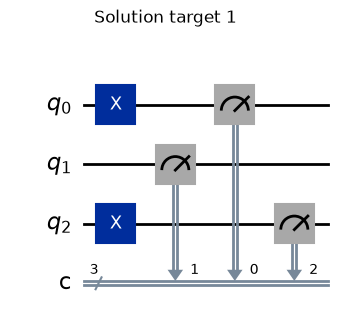

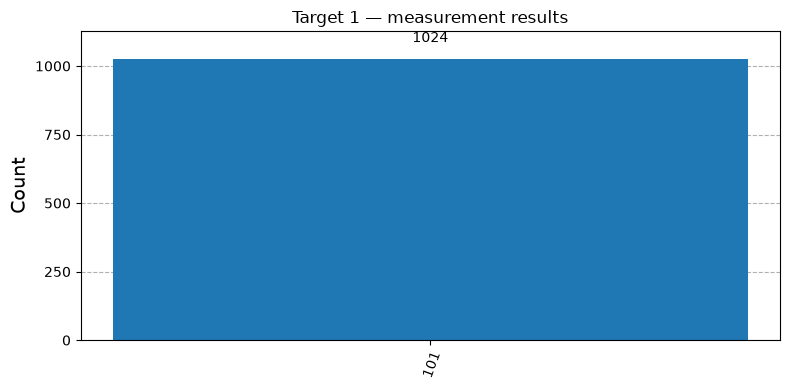

✅ Target 1 verified — counts: {'101': 1024}


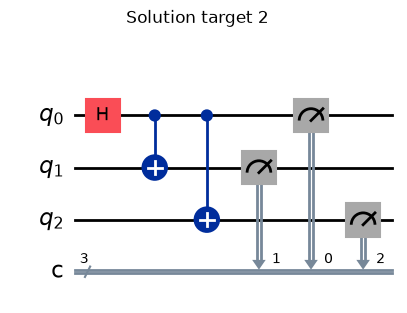

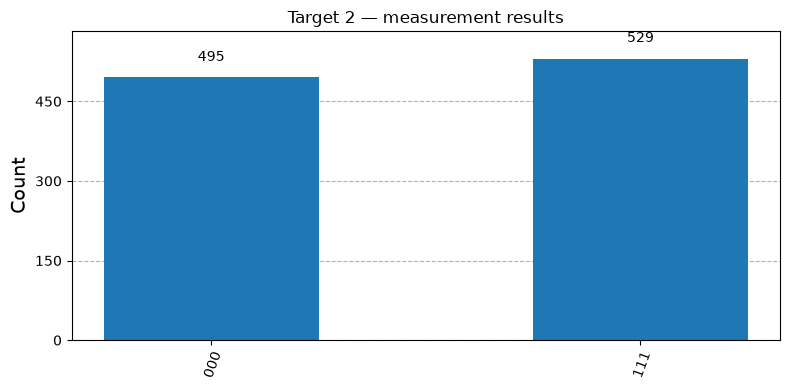

✅ Target 2 verified — counts: {'000': 495, '111': 529}


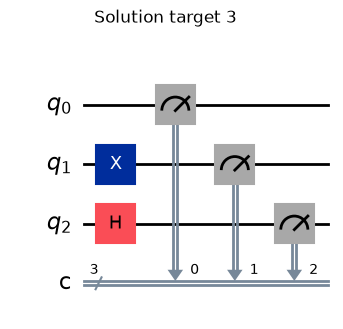

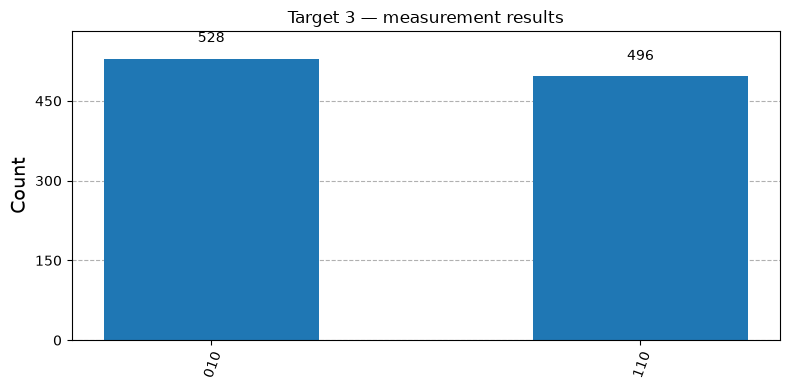

✅ Target 3 verified — counts: {'110': 496, '010': 528}


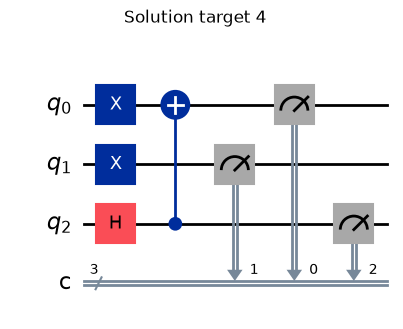

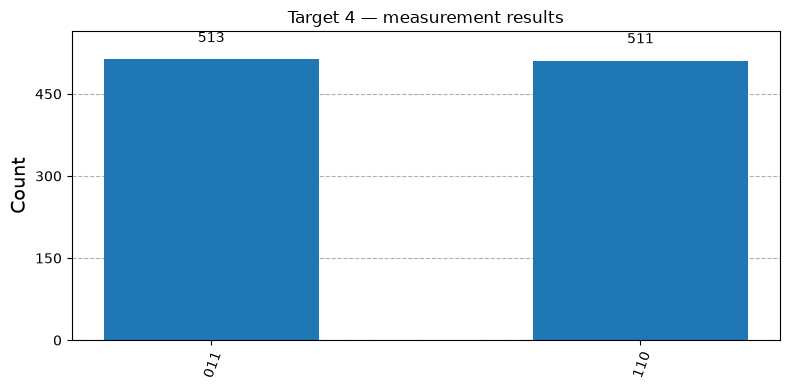

✅ Target 4 verified — counts: {'110': 511, '011': 513}


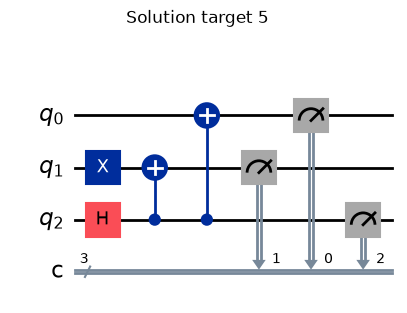

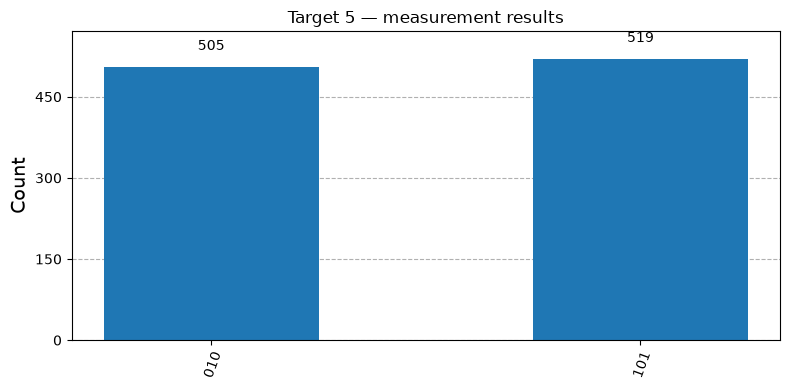

✅ Target 5 verified — counts: {'101': 519, '010': 505}


In [13]:
s = 1/np.sqrt(2)
targets = [target_1, target_2, target_3, target_4, target_5]
expected_counts = [
    {"101": 1.0},
    {"000": 0.5, "111": 0.5},
    {"010": 0.5, "110": 0.5},
    {"110": 0.5, "011": 0.5},
    {"101": 0.5, "010": 0.5},
]
expected_states = [
    {"101": 1.0},
    {"000": s, "111": s},
    {"010": s, "110": s},
    {"110": s, "011": s},
    {"101": s, "010": s},
]

for i, (build, exp_counts, exp_state) in enumerate(zip(targets, expected_counts, expected_states), start=1):
    qc = build()
    display(draw_circuit(qc, f"Solution target {i}"))
    counts = simulate(qc, shots=1024)
    display(plot_counts(counts, f"Target {i} — measurement results"))
    assert_statevector(qc, exp_state, message=f"Target {i} state")
    assert_distribution(counts, exp_counts, message=f"Target {i} counts")
    print(f"✅ Target {i} verified — counts: {counts}")

> **Teaching note on target 5 (the subtle one):** the two targets `101` and `010` differ on *all three* qubits. Qubit 0's bit (0→1) **follows** the seed → `CX(2,0)` with no pre-flip. Qubit 1's bit (1→0) **anti-follows** the seed → pre-flip it with `X(1)` first, then `CX(2,1)` copies the seed's flip on top, reversing it. Qubit 2 is the seed (`H(2)`). The full working derivation is in the table above. (The exact phase bookkeeping is easiest to *verify* with the statevector rather than derive in class — which is precisely the lesson: when in doubt, ask the simulator for the exact state.)

> **Alternative solutions exist** for every target (e.g. different seed choices, or `H` then `CX` in other orders). The self-check accepts any circuit that produces the right state — students are not graded on the exact gate sequence.

---
# Bonus — Running on real IBM Quantum (teacher notes)

- Requires `QISKIT_IBM_TOKEN` in `.env` (see `.env.example` + `README.md`).
- Free tier: ~10 minutes of execution per month per account — use **one shared class token** and run at most one circuit per exercise.
- Expect noisy counts: e.g. the Φ⁺ Bell state typically comes out ≈ 48–52% for each of `00`/`11`, plus a few stray `01`/`10` outcomes.
- Queues can take minutes; `run_on_ibm` blocks until the result is ready.

In [14]:
try:
    real_counts = run_on_ibm(bell_circuits["00"], shots=1024)
    print("Real hardware counts:", real_counts)
    plot_counts(real_counts, "Bell state on REAL IBM Quantum hardware")
except Exception as e:
    print("Skipped the real-hardware run (no problem!):")
    print(e)

qiskit_runtime_service._discover_account:WARNING:2026-10-07 18:18:38,593: Loading account with the given token. A saved account will not be used.


qiskit_runtime_service.__init__:WARNING:2026-10-07 18:18:42,066: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Qiskit hardware backend. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-07 18:18:42,513: Using instance: Qiskit hardware backend, plan: open


Running on real hardware: ibm_fez (qubits: 156)
Job db38q174b7jc73anerfg submitted — waiting for result (this can take a few minutes)...
Real hardware counts: {'00': 478, '11': 524, '01': 15, '10': 7}


---
# Answer key (one-liners)

1. **Ex 1:** `h(0)` → 50/50; statevector $[1/\sqrt2, 1/\sqrt2]$.
2. **Ex 2:** `h(0); cx(0,1)` after the X-gates for the start state → Φ⁺, Φ⁻, Ψ⁺, Ψ⁻ for starts 00, 01, 10, 11; 00/01 (and 10/11) share counts but differ by a relative phase.
3. **Ex 3:** $H=\tfrac{1}{\sqrt2}\big(\begin{smallmatrix}1&1\\1&-1\end{smallmatrix}\big)$, $X=\big(\begin{smallmatrix}0&1\\1&0\end{smallmatrix}\big)$, CX = 4×4 swap of `|10⟩↔|11⟩`; the Bell unitary's columns *are* the four Bell states.
4. **Ex 4:** see the table above; the self-check (`assert_statevector` + `assert_distribution`) is the ground truth.
5. **Bonus:** `run_on_ibm(bell_circuits["00"], shots=1024)` — expect ≈50/50 with noise.